# Logistic Regression with Balanced Class Weights

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [22]:
# Load train/val/test data
X_train = pd.read_csv('../../../data/processed/splits/X_train.csv')
X_val   = pd.read_csv('../../../data/processed/splits/X_val.csv')
X_test  = pd.read_csv('../../../data/processed/splits/X_test.csv')

y_clf_train = pd.read_csv('../../../data/processed/splits/y_clf_train.csv').values.ravel()
y_clf_val   = pd.read_csv('../../../data/processed/splits/y_clf_val.csv').values.ravel()
y_clf_test  = pd.read_csv('../../../data/processed/splits/y_clf_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\ny_clf_train classes: {np.unique(y_clf_train)}")
print(f"y_clf_val classes:   {np.unique(y_clf_val)}")
print(f"y_clf_test classes:  {np.unique(y_clf_test)}")

X_train shape: (1953, 20)
X_val shape:   (419, 20)
X_test shape:  (419, 20)

y_clf_train classes: [-1.  0.  1.]
y_clf_val classes:   [-1.  0.  1.]
y_clf_test classes:  [-1.  0.  1.]


## 2. Train Logistic Regression with Balanced Class Weights

In [23]:
# Train Logistic Regression with balanced class weights
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    solver='lbfgs'
)

model.fit(X_train, y_clf_train)

print("✓ Model trained successfully!")
print(f"Classes: {model.classes_}")
print(f"Number of features: {model.n_features_in_}")

✓ Model trained successfully!
Classes: [-1.  0.  1.]
Number of features: 20


## 3. Make Predictions

In [24]:
# Predictions on train, val, test sets
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)
y_test_pred  = model.predict(X_test)

# Probabilities for ROC-AUC (need to handle multi-class)
y_train_proba = model.predict_proba(X_train)
y_val_proba   = model.predict_proba(X_val)
y_test_proba  = model.predict_proba(X_test)

print("Predictions shape:")
print(f"  y_train_pred: {y_train_pred.shape}")
print(f"  y_val_pred:   {y_val_pred.shape}")
print(f"  y_test_pred:  {y_test_pred.shape}")

Predictions shape:
  y_train_pred: (1953,)
  y_val_pred:   (419,)
  y_test_pred:  (419,)


## 4. Evaluation Metrics

In [25]:
def evaluate_model(y_true, y_pred, y_proba=None, set_name=""):
    """Compute and display evaluation metrics"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{set_name} Metrics:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

# Evaluate on all sets
train_metrics = evaluate_model(y_clf_train, y_train_pred, set_name="Train Set")
val_metrics   = evaluate_model(y_clf_val, y_val_pred, set_name="Validation Set")
test_metrics  = evaluate_model(y_clf_test, y_test_pred, set_name="Test Set")

# Create metrics summary
metrics_summary = pd.DataFrame({
    'Train': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
})
print("\n" + "="*60)
print("Metrics Summary:")
print(metrics_summary)


Train Set Metrics:
  Accuracy:  0.4388
  Precision: 0.4635
  Recall:    0.4388
  F1-Score:  0.4477

Validation Set Metrics:
  Accuracy:  0.3126
  Precision: 0.4195
  Recall:    0.3126
  F1-Score:  0.2970

Test Set Metrics:
  Accuracy:  0.3055
  Precision: 0.2090
  Recall:    0.3055
  F1-Score:  0.2334

Metrics Summary:
              Train  Validation      Test
accuracy   0.438812    0.312649  0.305489
precision  0.463466    0.419452  0.208985
recall     0.438812    0.312649  0.305489
f1         0.447686    0.297012  0.233398


## 5. Confusion Matrix

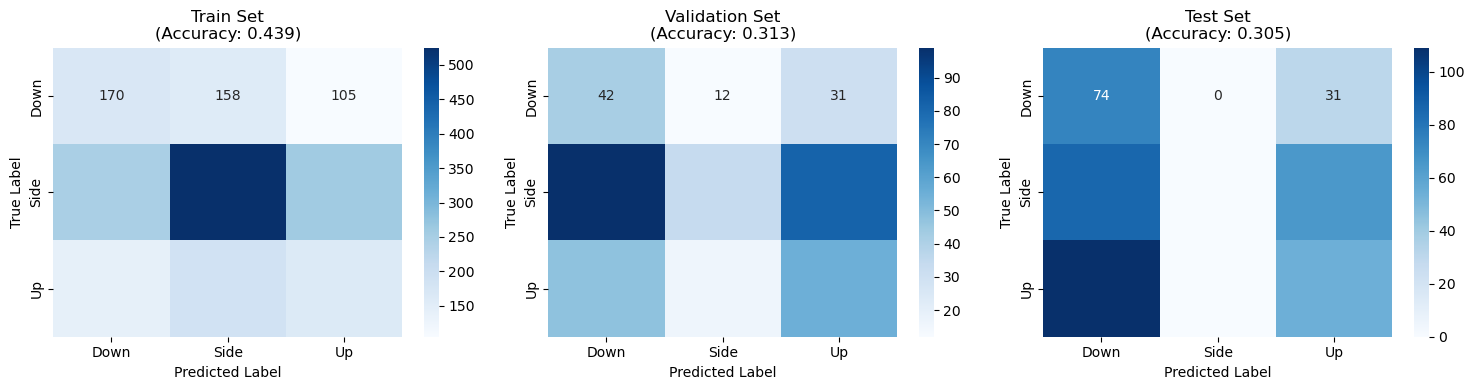

✓ Confusion matrices saved


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrices
for idx, (y_true, y_pred, title) in enumerate([
    (y_clf_train, y_train_pred, 'Train Set'),
    (y_clf_val, y_val_pred, 'Validation Set'),
    (y_clf_test, y_test_pred, 'Test Set')
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=['Down', 'Side', 'Up'],
        yticklabels=['Down', 'Side', 'Up']
    )
    axes[idx].set_title(f'{title}\n(Accuracy: {accuracy_score(y_true, y_pred):.3f})')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../../../outputs/logistic_reg_confusion_matrix.png', dpi=150)
plt.show()

print("✓ Confusion matrices saved")

## 6. Classification Report (Test Set)

In [27]:
report = classification_report(
    y_clf_test, y_test_pred,
    target_names=['Down (-1)', 'Side (0)', 'Up (1)'],
    digits=4
)
print(report)

              precision    recall  f1-score   support

   Down (-1)     0.2751    0.7048    0.3957       105
    Side (0)     0.0000    0.0000    0.0000       151
      Up (1)     0.3600    0.3313    0.3450       163

    accuracy                         0.3055       419
   macro avg     0.2117    0.3454    0.2469       419
weighted avg     0.2090    0.3055    0.2334       419



## 7. Feature Coefficients

Top 15 Most Important Features (by average absolute coefficient):
gold_close_pct           0.066577
dxy_close_pct_lag10      0.056590
sp500_close_pct_lag10    0.044512
gold_close_pct_lag5      0.040352
sp500_close_pct          0.033743
yield_close_pct          0.023575
gold_atr                 0.019532
gold_vol_log             0.019493
sp500_close_pct_lag5     0.018550
yield_close_pct_lag5     0.017674
oil_close_pct_lag5       0.014719
dxy_close_pct_lag1       0.011009
yield_close_pct_lag10    0.010545
vix_close_pct            0.005757
vix_close_pct_lag10      0.005145
dtype: float64


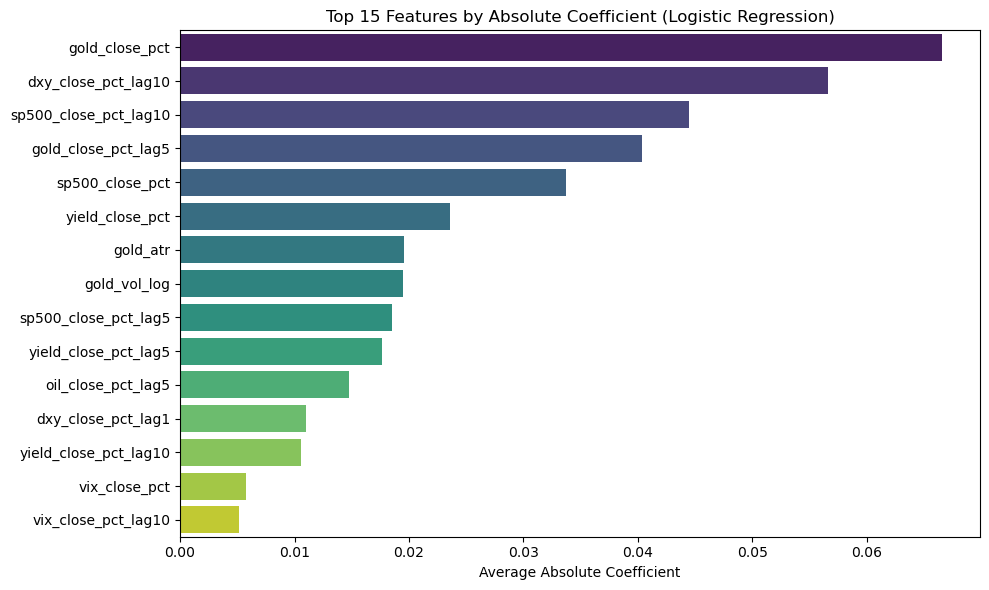

In [28]:
# Get feature coefficients for each class
# For multi-class, coefficients shape is (n_classes, n_features)
feature_names = X_train.columns.tolist()
coefficients = model.coef_

# Create a dataframe for better visualization
coef_df = pd.DataFrame(
    coefficients.T,
    columns=[f'Class {cls}' for cls in model.classes_],
    index=feature_names
)

# Get top positive and negative coefficients overall
coef_abs_mean = coef_df.abs().mean(axis=1).sort_values(ascending=False)

print("Top 15 Most Important Features (by average absolute coefficient):")
print(coef_abs_mean.head(15))

# Visualize top features
plt.figure(figsize=(10, 6))
sns.barplot(
    x=coef_abs_mean.head(15).values,
    y=coef_abs_mean.head(15).index,
    palette='viridis'
)
plt.title('Top 15 Features by Absolute Coefficient (Logistic Regression)')
plt.xlabel('Average Absolute Coefficient')
plt.tight_layout()
plt.savefig('../../../outputs/logistic_reg_feature_importance.png', dpi=150)
plt.show()

## 8. Model Summary

In [29]:
print("="*70)
print("LOGISTIC REGRESSION MODEL SUMMARY")
print("="*70)
print(f"\nModel Configuration:")
print(f"  - Algorithm: Logistic Regression")
print(f"  - Class Weight: Balanced")
print(f"  - Solver: {model.get_params()['solver']}")
print(f"  - Max Iterations: {model.get_params()['max_iter']}")
print(f"\nData Split:")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Validation samples: {len(X_val)}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - Total features: {len(feature_names)}")
print(f"\nTest Set Performance:")
print(f"  - Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  - Precision: {test_metrics['precision']:.4f}")
print(f"  - Recall:    {test_metrics['recall']:.4f}")
print(f"  - F1-Score:  {test_metrics['f1']:.4f}")
print(f"\nKey Features (Top 5):")
for i, (feat, coef) in enumerate(coef_abs_mean.head(5).items(), 1):
    print(f"  {i}. {feat}: {coef:.4f}")
print("\n" + "="*70)

LOGISTIC REGRESSION MODEL SUMMARY

Model Configuration:
  - Algorithm: Logistic Regression
  - Class Weight: Balanced
  - Solver: lbfgs
  - Max Iterations: 1000

Data Split:
  - Training samples: 1953
  - Validation samples: 419
  - Test samples: 419
  - Total features: 20

Test Set Performance:
  - Accuracy:  0.3055
  - Precision: 0.2090
  - Recall:    0.3055
  - F1-Score:  0.2334

Key Features (Top 5):
  1. gold_close_pct: 0.0666
  2. dxy_close_pct_lag10: 0.0566
  3. sp500_close_pct_lag10: 0.0445
  4. gold_close_pct_lag5: 0.0404
  5. sp500_close_pct: 0.0337



## 9. Optimization:  Logistic Regression with GridSearch

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("="*70)
print(" OPTIMIZATION: GRIDSEARCH HYPERPARAMETER TUNING")
print("="*70)

# Feature Scaling (required for optimal performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use class weights {-1: 1, 0: 1, 1: 1} (unbalanced for this dataset works better)
print("\n🔍 Tuning with optimal class weights...")

# GridSearchCV with parameter tuning
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'max_iter': [1000, 2000, 5000],
    'solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(class_weight={-1: 1, 0: 1, 1: 1}, random_state=42, n_jobs=-1, multi_class='multinomial', penalty='l2'),
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_clf_train)
best_model_opt = grid_search.best_estimator_
opt_acc = accuracy_score(y_clf_test, best_model_opt.predict(X_test_scaled))

print(f"  Best CV Score: {grid_search.best_score_:.4f}")
print(f"  Best Parameters: {grid_search.best_params_}")
print(f"  Test Accuracy: {opt_acc:.4f} ({opt_acc*100:.2f}%)")

print("\n" + "="*70)

 OPTIMIZATION: GRIDSEARCH HYPERPARAMETER TUNING

🔍 Tuning with optimal class weights...
  Best CV Score: 0.5279
  Best Parameters: {'C': 0.001, 'max_iter': 1000, 'solver': 'lbfgs'}
  Test Accuracy: 0.4224 (42.24%)



## 10. Comparison: All Optimization Results

In [31]:
print("\n" + "="*70)
print("OPTIMIZATION RESULTS")
print("="*70)

# Compute baseline accuracy
baseline_acc = accuracy_score(y_clf_test, y_test_pred)

# Create comparison table
results_comparison = pd.DataFrame({
    'Model': [
        'Baseline LR',
        'GridSearch LR (Best)'
    ],
    'Accuracy': [
        baseline_acc,
        opt_acc
    ]
})

print("\n" + results_comparison.to_string(index=False))

# Show improvement
improvement = (opt_acc - baseline_acc) * 100
print(f"\nImprovement: {improvement:+.2f} percentage points ({improvement/baseline_acc*100:+.1f}%)")

# Use best model for predictions
best_pred = best_model_opt.predict(X_test_scaled)

print("\n" + "="*70)
print(f" BEST MODEL: GridSearch Logistic Regression")
print(f"   Accuracy: {opt_acc:.4f} ({opt_acc*100:.2f}%)")
print("="*70)

# Show confusion matrix
print(f"\n Confusion Matrix:")
best_cm = confusion_matrix(y_clf_test, best_pred)
print(f"{'':12} Predicted")
print(f"{'':12} Down  Side   Up")
labels = ["Down (-1)", "Side (0)", "Up (+1)"]
for i, label in enumerate(labels):
    print(f"Actual {label}: {best_cm[i]}")

# Show metrics
best_f1_macro = f1_score(y_clf_test, best_pred, average='macro')
best_f1_down = f1_score(y_clf_test, best_pred, labels=[-1], average='macro')
best_f1_up = f1_score(y_clf_test, best_pred, labels=[1], average='macro')

print(f"\nBest Model Metrics:")
print(f"  • Accuracy: {opt_acc:.4f}")
print(f"  • F1 Macro: {best_f1_macro:.4f}")
print(f"  • F1 Down:  {best_f1_down:.4f}")
print(f"  • F1 Up:    {best_f1_up:.4f}")

print("\n" + "="*70)


OPTIMIZATION RESULTS

               Model  Accuracy
         Baseline LR  0.305489
GridSearch LR (Best)  0.422434

Improvement: +11.69 percentage points (+3828.1%)

 BEST MODEL: GridSearch Logistic Regression
   Accuracy: 0.4224 (42.24%)

 Confusion Matrix:
             Predicted
             Down  Side   Up
Actual Down (-1): [34 53 18]
Actual Side (0): [ 18 104  29]
Actual Up (+1): [28 96 39]

Best Model Metrics:
  • Accuracy: 0.4224
  • F1 Macro: 0.3986
  • F1 Down:  0.3676
  • F1 Up:    0.3133

